# Relative Performance & Normalized Gains

Goal: quantify how close each method is to the per-step best and compute gains over baseline.

Expected takeaway: methods that are consistently near-best and those with strongest gains.


In [1]:
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Robust data directory resolver (works from repo root or final_results/tools)

def get_data_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = []
    for parent in [cwd] + list(cwd.parents):
        candidates.append(parent / "final_results" / "data")
        candidates.append(parent / "data")
    for c in candidates:
        if c.exists():
            return c
    raise FileNotFoundError(f"Could not locate data directory in candidates: {candidates}")

DATA_DIR = get_data_dir()

combined = pd.read_csv(DATA_DIR / "combined_wide.csv")
combined = combined.drop(columns=[c for c in combined.columns if c.lower().startswith("unnamed")], errors="ignore")
combined["Step"] = pd.to_numeric(combined["Step"], errors="coerce")
combined["seed"] = combined["seed"].astype(str)

metric_cols = ["avg@32", "pass@1", "pass@2", "pass@4", "pass@8", "pass@16", "pass@32", "pass@64", "pass@128"]
for c in metric_cols:
    combined[c] = pd.to_numeric(combined[c], errors="coerce")

passk_cols = [c for c in metric_cols if c.startswith("pass@")]
passk_ks = [int(c.split("@")[1]) for c in passk_cols]

final_step = int(combined["Step"].max())

# Aggregate across seeds for smoother curves
agg = combined.groupby(["Step", "algorithm"], as_index=False)[metric_cols].mean()

PLOT_COUNTER = 0

def new_fig(title: str):
    global PLOT_COUNTER
    PLOT_COUNTER += 1
    plt.figure()
    plt.title(title)


In [2]:
baseline = "qwen2.5-1.5b-2gpu-PPO"
metrics = ["pass@1", "pass@8", "pass@32", "avg@32"]

# Normalize by per-step best
norm_rows = []
for metric in metrics:
    for step in sorted(agg["Step"].unique()):
        sub = agg[agg["Step"] == step]
        best = sub[metric].max()
        for _, r in sub.iterrows():
            norm_rows.append({"Step": step, "algorithm": r["algorithm"], "metric": metric, "norm": r[metric] / best if best else np.nan})

norm = pd.DataFrame(norm_rows)


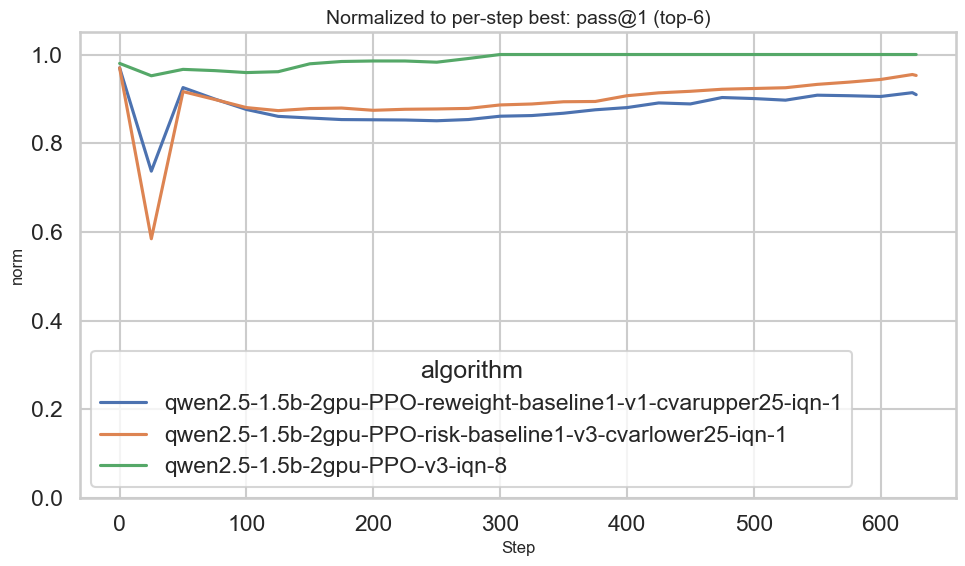

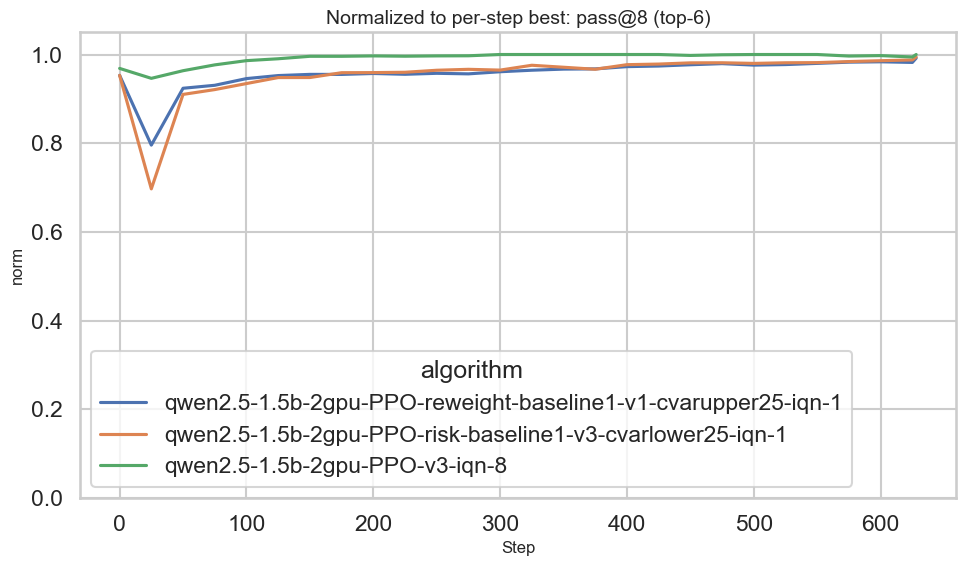

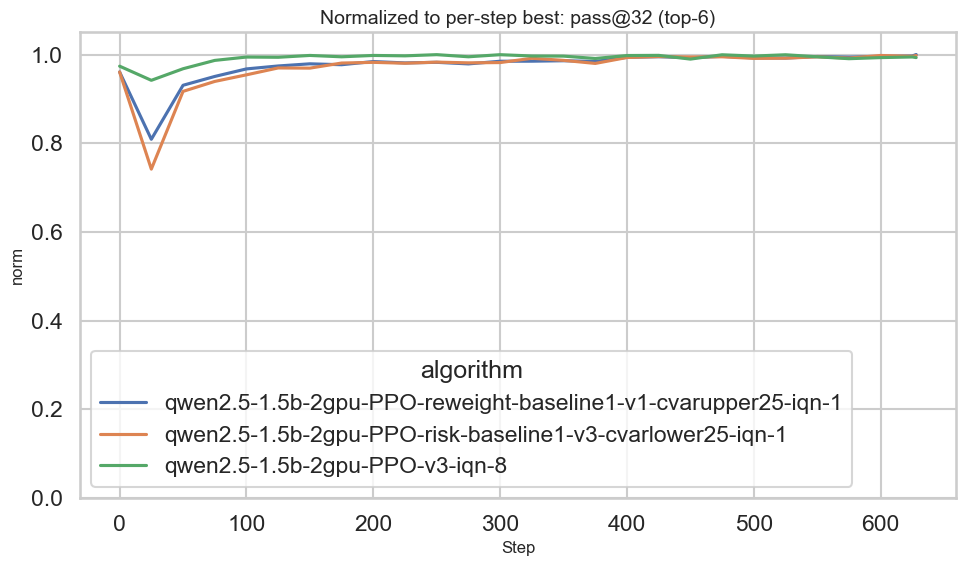

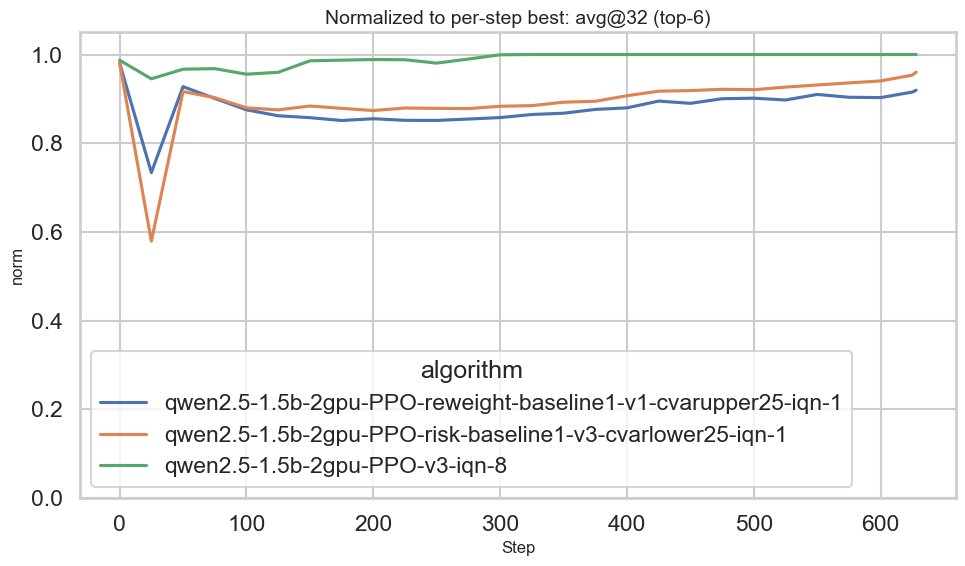

In [3]:
# Plot 1: normalized curves for top-6 final methods
for metric in metrics:
    final = agg[agg["Step"] == final_step].sort_values(metric, ascending=False)
    tops = final["algorithm"].head(6).tolist()
    new_fig(f"Normalized to per-step best: {metric} (top-6)")
    sns.lineplot(data=norm[(norm["metric"] == metric) & (norm["algorithm"].isin(tops))], x="Step", y="norm", hue="algorithm")
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()


/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_95968/3095040377.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  score = sub.groupby("algorithm").apply(lambda df: np.trapz(df["norm"], df["Step"]))
/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_95968/3095040377.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


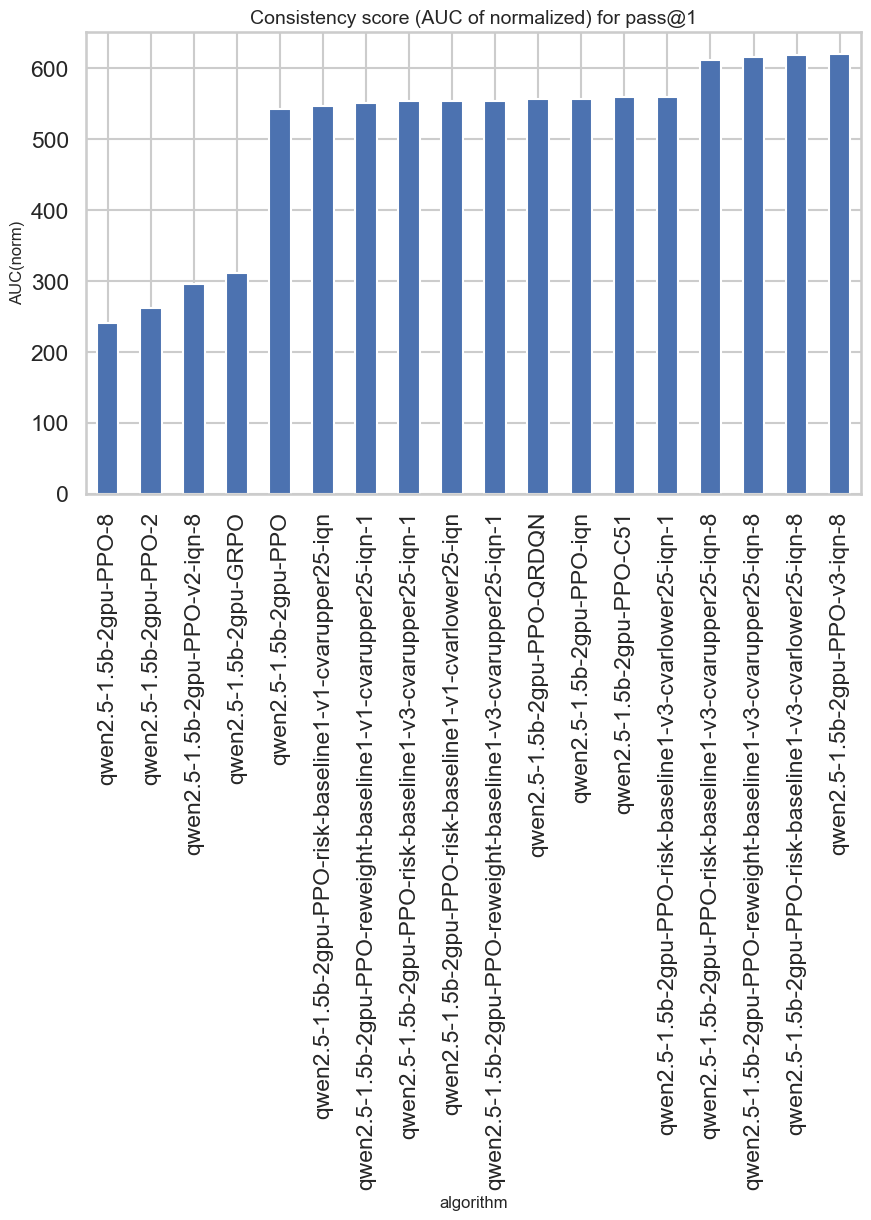

/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_95968/3095040377.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  score = sub.groupby("algorithm").apply(lambda df: np.trapz(df["norm"], df["Step"]))
/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_95968/3095040377.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


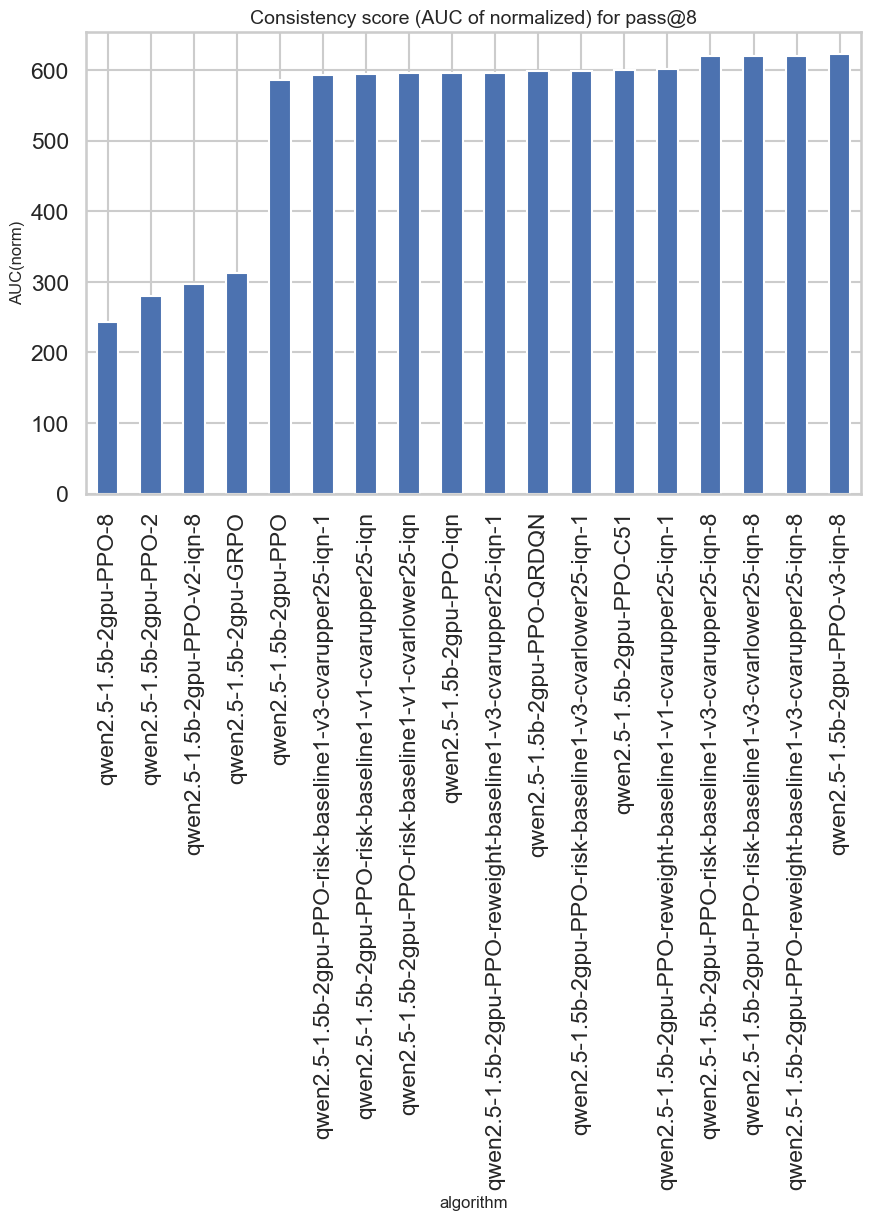

/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_95968/3095040377.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  score = sub.groupby("algorithm").apply(lambda df: np.trapz(df["norm"], df["Step"]))
/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_95968/3095040377.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


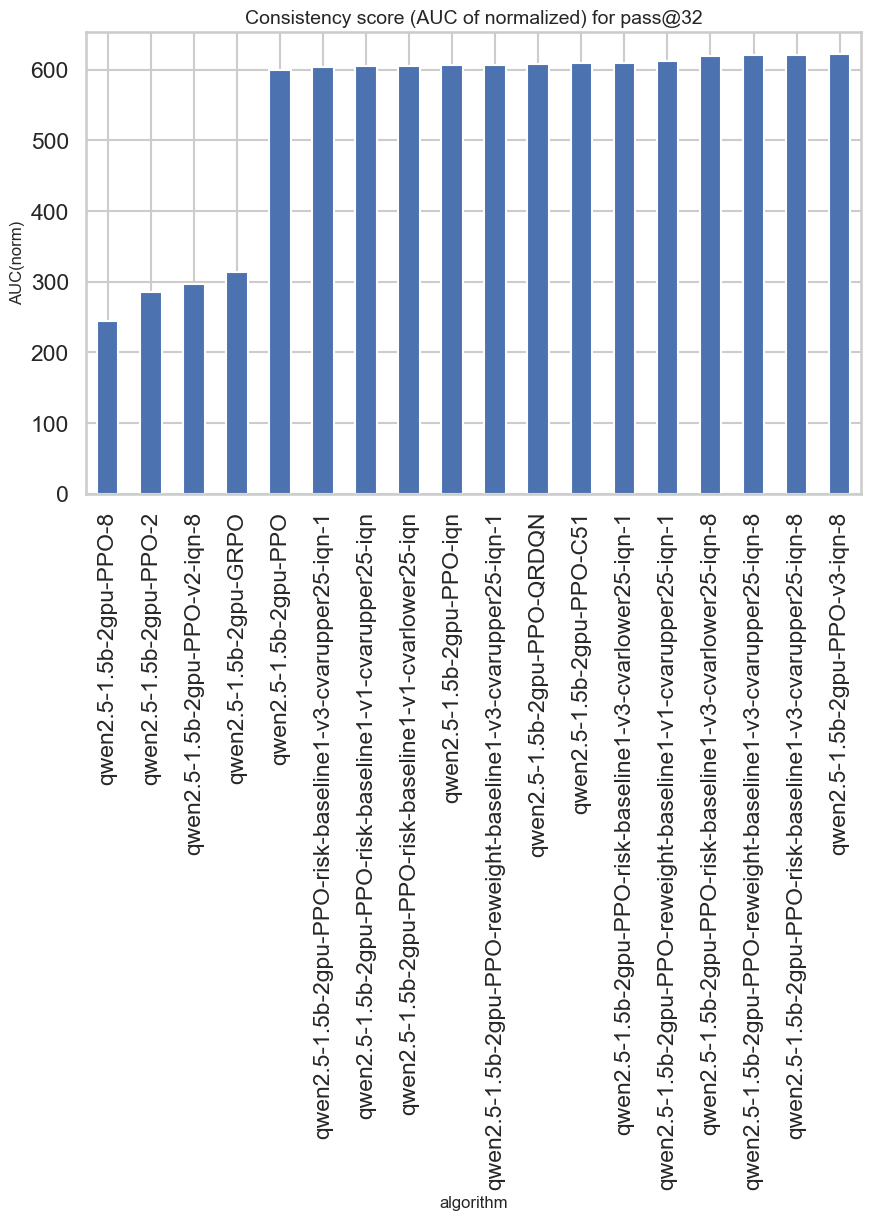

/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_95968/3095040377.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  score = sub.groupby("algorithm").apply(lambda df: np.trapz(df["norm"], df["Step"]))
/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_95968/3095040377.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


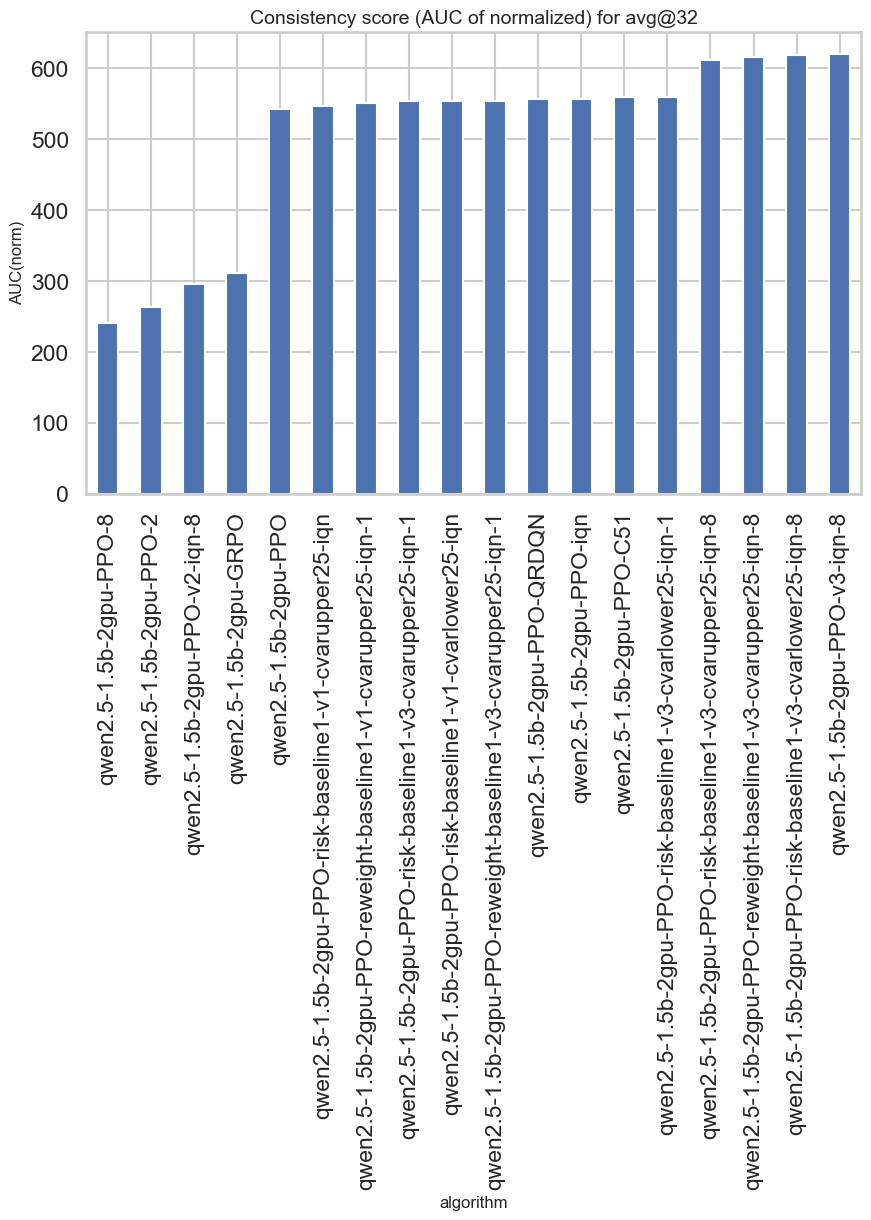

In [4]:
# Plot 2: area under normalized curve (consistency score)
for metric in metrics:
    sub = norm[norm["metric"] == metric]
    score = sub.groupby("algorithm").apply(lambda df: np.trapz(df["norm"], df["Step"]))
    new_fig(f"Consistency score (AUC of normalized) for {metric}")
    score.sort_values().plot(kind="bar")
    plt.ylabel("AUC(norm)")
    plt.tight_layout()
    plt.show()


/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_95968/3257903357.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  deltas.append({"algorithm": algo, "auc_delta": np.trapz(merged["delta"], merged["Step"])})
/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_95968/3257903357.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  deltas.append({"algorithm": algo, "auc_delta": np.trapz(merged["delta"], merged["Step"])})
/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_95968/3257903357.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  deltas.append({"algorithm": algo, "auc_delta": np.trapz(merged["delta"], merged["Step"])})
/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_95968

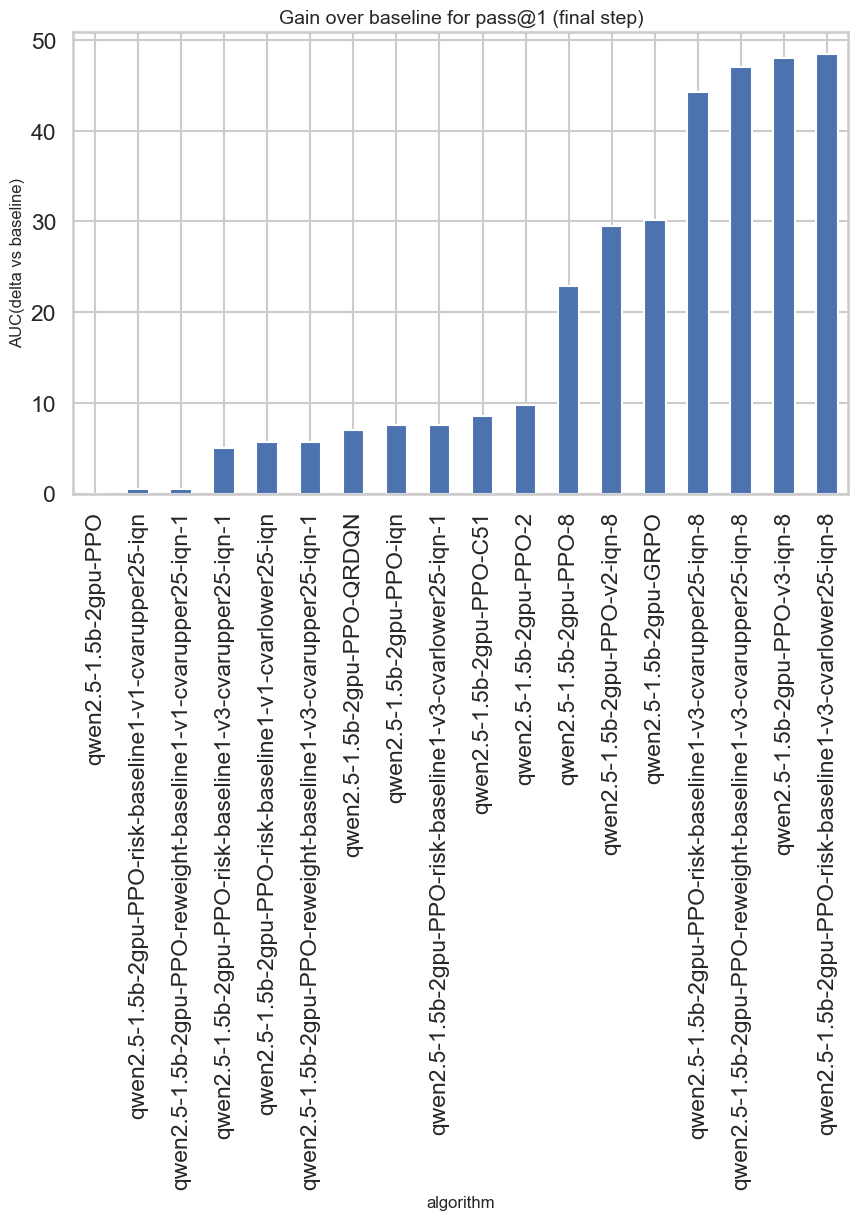

/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_95968/3257903357.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  deltas.append({"algorithm": algo, "auc_delta": np.trapz(merged["delta"], merged["Step"])})
/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_95968/3257903357.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  deltas.append({"algorithm": algo, "auc_delta": np.trapz(merged["delta"], merged["Step"])})
/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_95968/3257903357.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  deltas.append({"algorithm": algo, "auc_delta": np.trapz(merged["delta"], merged["Step"])})
/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_95968

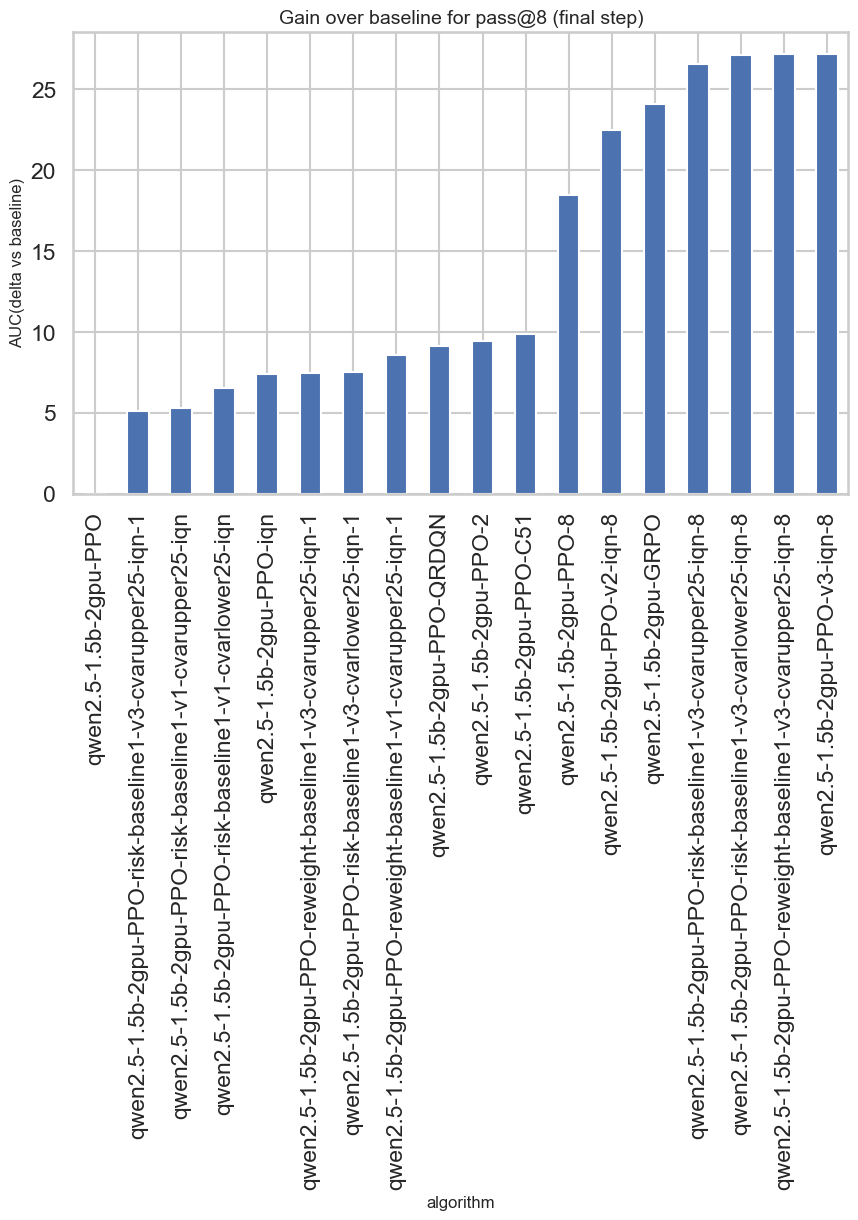

/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_95968/3257903357.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  deltas.append({"algorithm": algo, "auc_delta": np.trapz(merged["delta"], merged["Step"])})
/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_95968/3257903357.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  deltas.append({"algorithm": algo, "auc_delta": np.trapz(merged["delta"], merged["Step"])})
/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_95968/3257903357.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  deltas.append({"algorithm": algo, "auc_delta": np.trapz(merged["delta"], merged["Step"])})
/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_95968

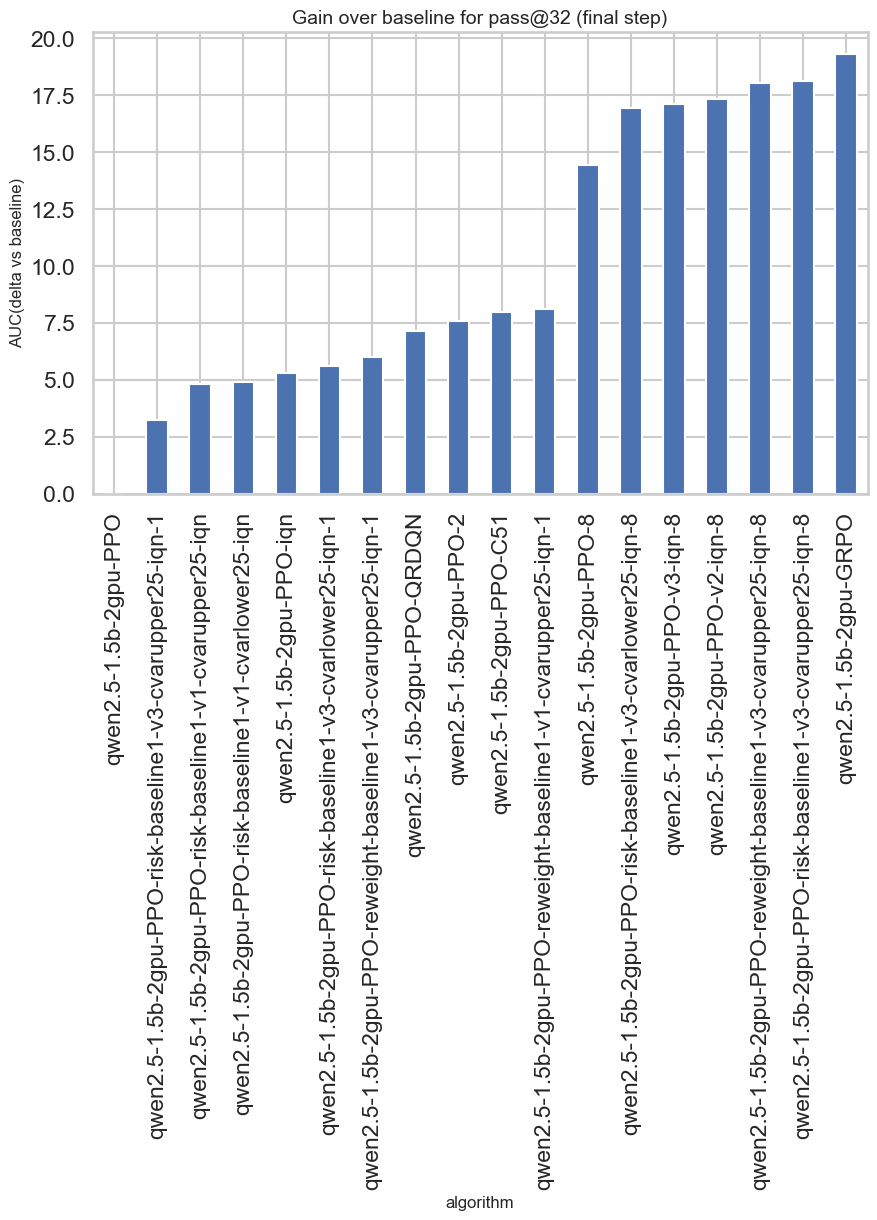

/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_95968/3257903357.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  deltas.append({"algorithm": algo, "auc_delta": np.trapz(merged["delta"], merged["Step"])})
/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_95968/3257903357.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  deltas.append({"algorithm": algo, "auc_delta": np.trapz(merged["delta"], merged["Step"])})
/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_95968/3257903357.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  deltas.append({"algorithm": algo, "auc_delta": np.trapz(merged["delta"], merged["Step"])})
/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_95968

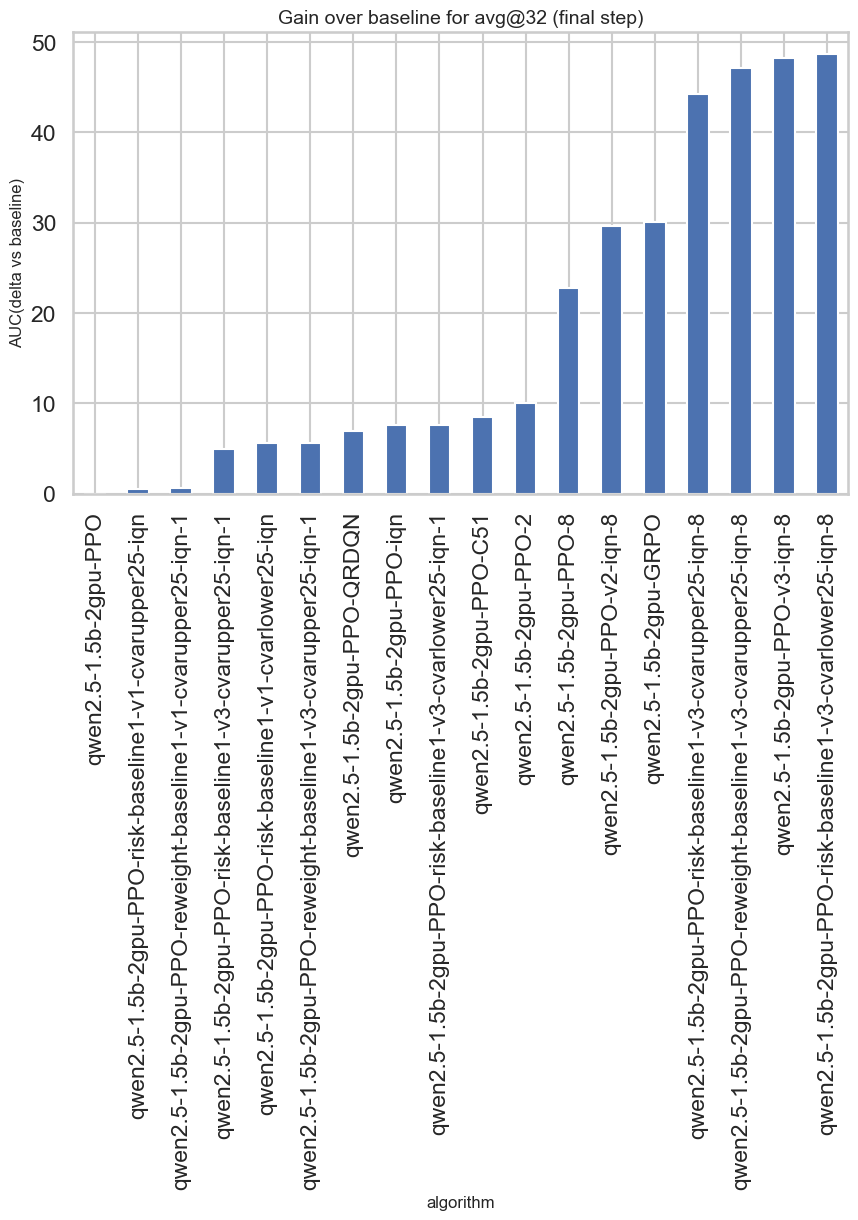

Generated 12 figures


In [5]:
# Plot 3: gain over baseline (per-step difference + AUC)
if baseline in agg["algorithm"].unique():
    for metric in metrics:
        base = agg[agg["algorithm"] == baseline][["Step", metric]].rename(columns={metric: "baseline"})
        new_fig(f"Gain over baseline for {metric} (final step)" )
        deltas = []
        for algo in agg["algorithm"].unique():
            sub = agg[agg["algorithm"] == algo][["Step", metric]].rename(columns={metric: "value"})
            merged = pd.merge(sub, base, on="Step", how="inner")
            merged["delta"] = merged["value"] - merged["baseline"]
            deltas.append({"algorithm": algo, "auc_delta": np.trapz(merged["delta"], merged["Step"])})
        pd.DataFrame(deltas).set_index("algorithm")["auc_delta"].sort_values().plot(kind="bar")
        plt.ylabel("AUC(delta vs baseline)")
        plt.tight_layout()
        plt.show()

print(f"Generated {PLOT_COUNTER} figures")
